In [1]:
import numpy as np
import pandas as pd
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
import warnings
warnings.filterwarnings('ignore')

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,8,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,9,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,9,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,12,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,12,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,33,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,13,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,27,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,17,0,0


In [6]:
dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,291,250,541,11.14%
1,2011,356,31,387,7.97%
2,2012,361,20,381,7.85%
3,2013,363,21,384,7.91%
4,2014,380,0,380,7.83%
5,2015,380,0,380,7.83%
6,2016,380,0,380,7.83%
7,2017,380,0,380,7.83%
8,2018,311,117,428,8.81%
9,2019,344,53,397,8.18%


In [8]:
feature_list = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns.tolist()

In [9]:
#Use all data for training

ft_importance = pd.DataFrame()

for feature in feature_list:
    print(f"Training without feature: '{feature}'")
    X_train = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
    y_train = dataset['case']

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)

    imputer = KNNImputer()
    X_train = imputer.fit_transform(X_train)

    try:
        class_0_counts = y_train.value_counts()[0]
    except KeyError:
        class_0_counts = 0
    try:
        class_1_counts = y_train.value_counts()[1]
    except KeyError:
        class_1_counts = 0
        
    if (near_u != 0):
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
        X_train, y_train = nm.fit_resample(X_train, y_train)
    
    if (smote != 0):
        class_0_counts = y_train.value_counts()[0]
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_train)

    loss = log_loss(y_train, probabilities)

    ft_importance = ft_importance.append({'Feature': feature,
                                          'Loss': loss}, ignore_index = True)

Training without feature: 'x'
Training without feature: 'y'
Training without feature: 'lau1_id'
Training without feature: 'day'
Training without feature: 'month'
Training without feature: 'week'
Training without feature: 'year'
Training without feature: 'day_sin'
Training without feature: 'day_cos'
Training without feature: 'month_sin'
Training without feature: 'month_cos'
Training without feature: 'week_sin'
Training without feature: 'week_cos'
Training without feature: 'area'
Training without feature: 'population'
Training without feature: 'population_density'
Training without feature: 'eq_distance'
Training without feature: 'ndvi'
Training without feature: 'ndmi'
Training without feature: 'ndwi'
Training without feature: 'ndbi'
Training without feature: 'ndvi_mean'
Training without feature: 'ndmi_mean'
Training without feature: 'ndwi_mean'
Training without feature: 'ndbi_mean'
Training without feature: 'ndvi_std'
Training without feature: 'ndmi_std'
Training without feature: 'ndwi_s

In [10]:
# Split in train and test

# ft_importance = pd.DataFrame()

# for feature in feature_list:
#     print(f"Training without feature: '{feature}'")
#     X = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
#     y = dataset['case']

#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify = y, random_state = 0)

#     scaler = MinMaxScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_test = scaler.transform(X_test)

#     imputer = KNNImputer()
#     X_train = imputer.fit_transform(X_train)
#     X_test = imputer.transform(X_test)

#     try:
#         class_0_counts = y_train.value_counts()[0]
#     except KeyError:
#         class_0_counts = 0
#     try:
#         class_1_counts = y_train.value_counts()[1]
#     except KeyError:
#         class_1_counts = 0
        
#     if (near_u != 0):
#         nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
#         X_train, y_train = nm.fit_resample(X_train, y_train)
    
#     if (smote != 0):
#         class_0_counts = y_train.value_counts()[0]
#         sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
#         X_train, y_train = sm.fit_resample(X_train, y_train)

#     w0,w1 = calculate_weights(y_train)

#     model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
#     model.fit(X_train, y_train)

#     probabilities_test = model.predict_proba(X_test)

#     loss = log_loss(y_test, probabilities_test)

#     ft_importance = ft_importance.append({'Feature': feature,
#                                           'Loss': loss}, ignore_index = True)

In [11]:
ft_importance.sort_values(by=['Loss'], ascending=True, inplace=True)

In [12]:
losses = ft_importance['Loss']
shp = losses.shape[0]
losses = losses.to_numpy().reshape(1,shp)

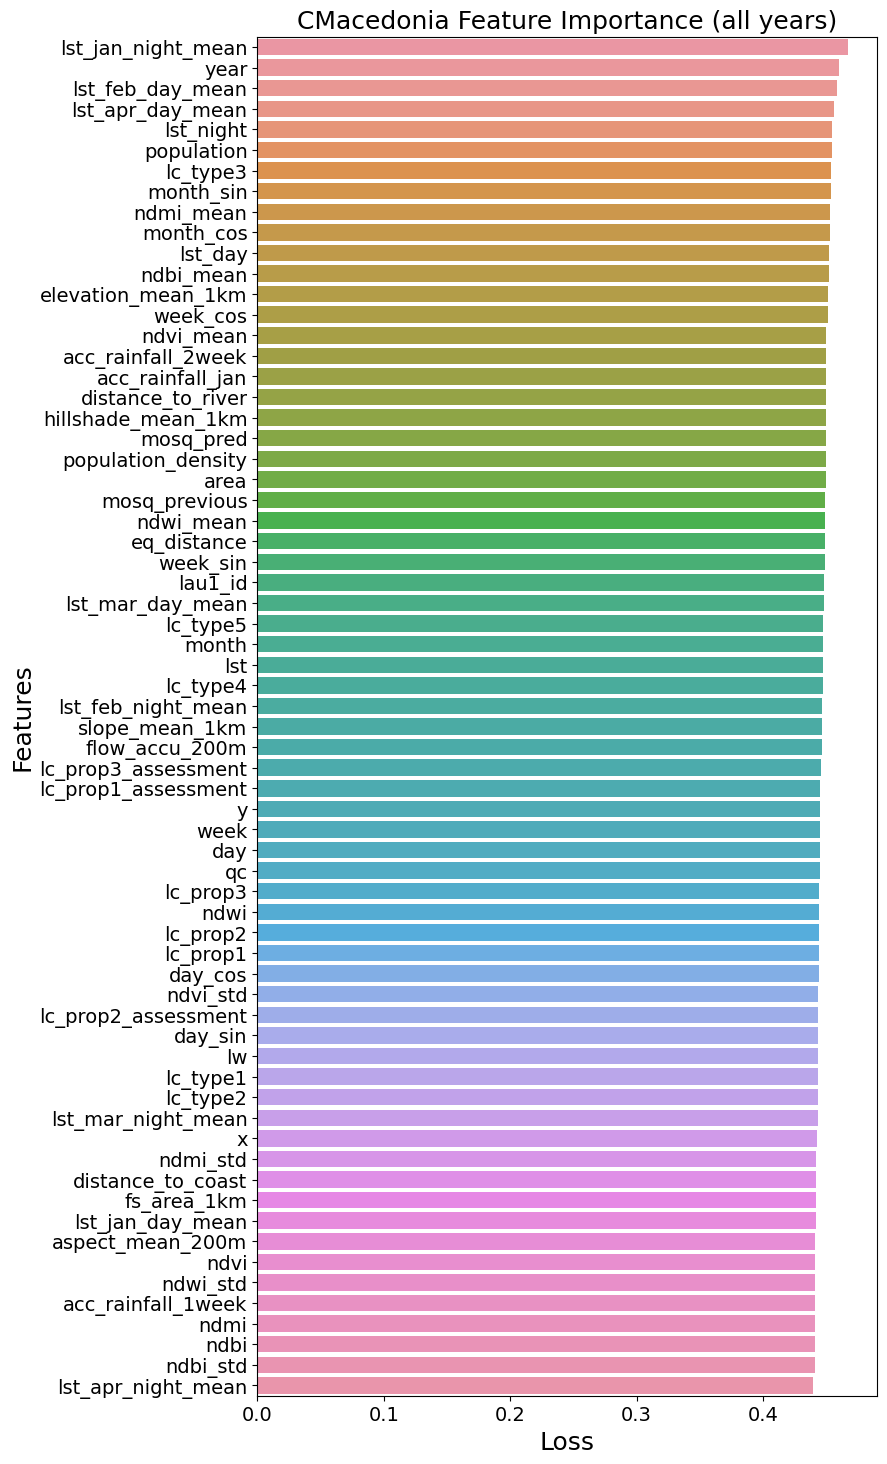

In [13]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Loss', title = f'{NUTS2} Feature Importance (all years)', title_size=18)

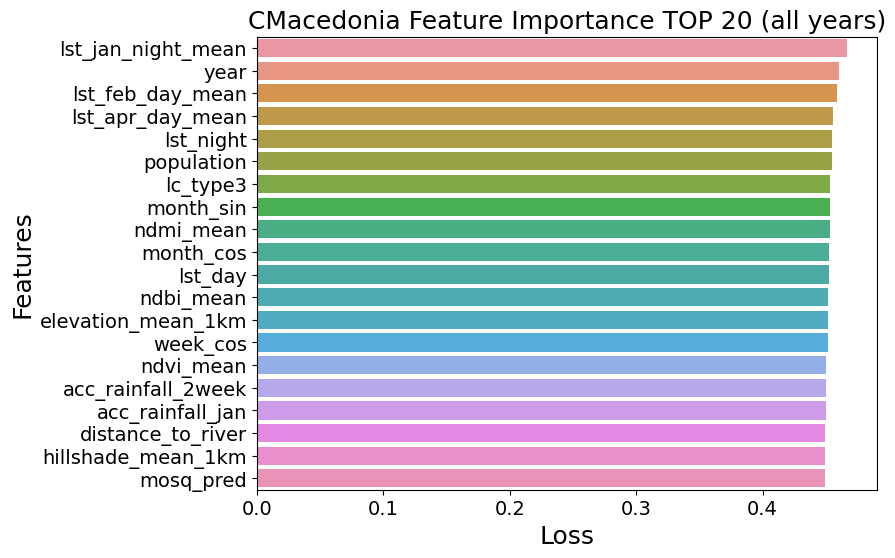

In [14]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Loss', title = f'{NUTS2} Feature Importance TOP 20 (all years)', title_size=18, top = 20, figure_size=(8,6))

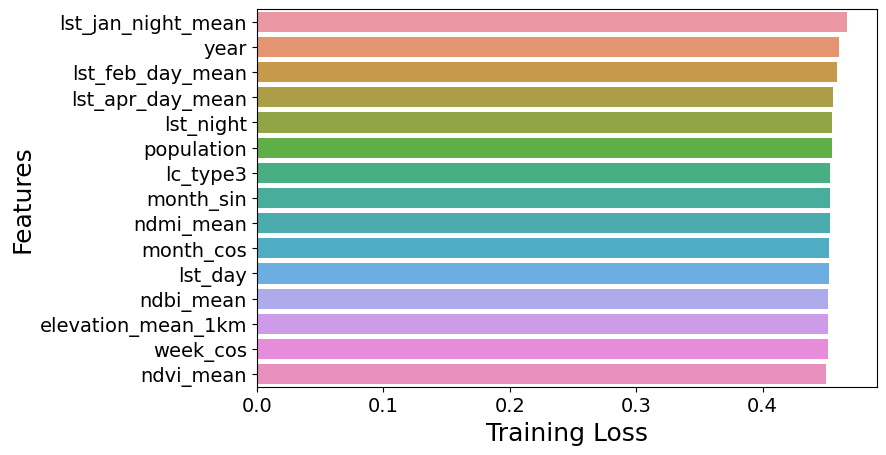

In [15]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Training Loss', top = 15, figure_size= (8,5))